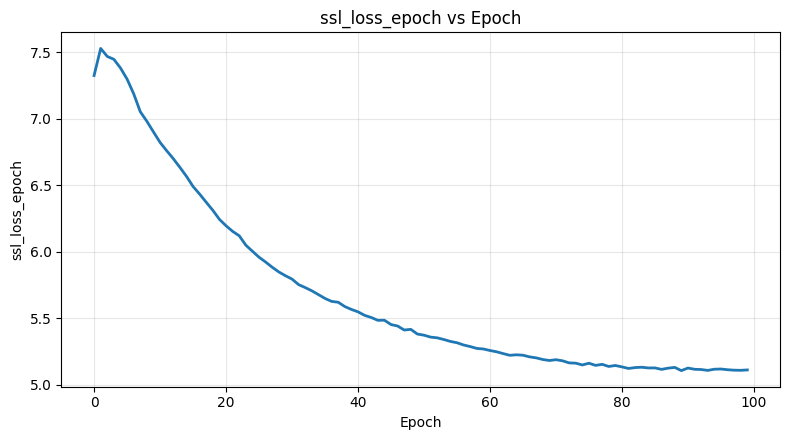

In [ ]:
from pathlib import Path
import pandas as pd

import matplotlib.pyplot as plt

ssl_csv_path = Path("../logs/train/SurfaceDefectDetection/MoCoV2/2026-01-19_16-11-15_mobilenetv3_large/run_0/ssl_log/metrics.csv")

df = pd.read_csv(ssl_csv_path)

# Try to locate the epoch and ssl loss columns robustly
epoch_col = next((c for c in df.columns if c.lower() == "epoch"), None)
loss_col = next((c for c in df.columns if c.lower() == "ssl_loss_epoch"), None)

if epoch_col is None or loss_col is None:
    raise ValueError(f"Required columns not found. Available columns: {list(df.columns)}")

plot_df = df[[epoch_col, loss_col]].dropna().sort_values(epoch_col)

plt.figure(figsize=(8, 4.5))
plt.plot(plot_df[epoch_col], plot_df[loss_col], linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("ssl_loss_epoch")
plt.title("ssl_loss_epoch vs Epoch")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

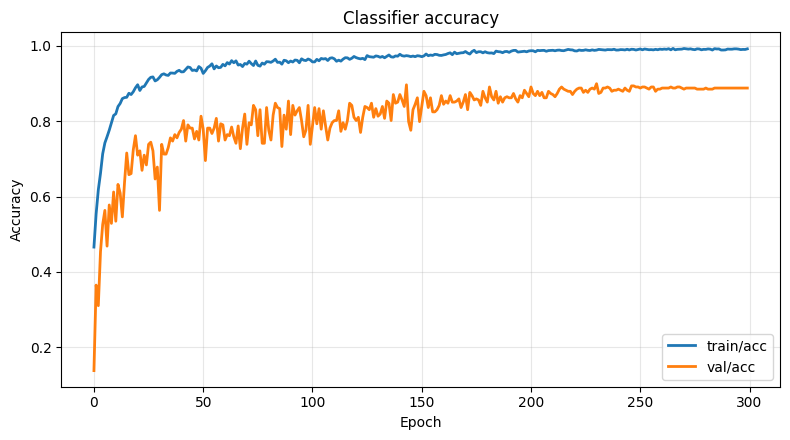

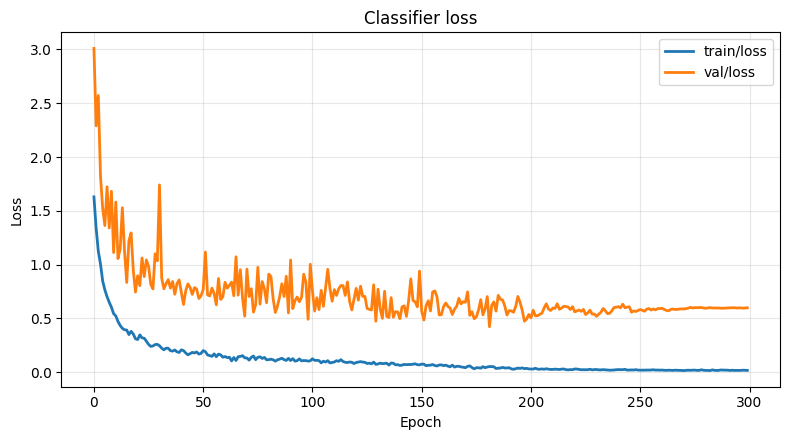

In [23]:
from pathlib import Path
import pandas as pd

import matplotlib.pyplot as plt

classifier_csv_path = Path("../logs/train/SurfaceDefectDetection/Loss_CE/2026-01-21_09-19-39_mobilenet_strong_aug/run_0/metrics.csv")

df = pd.read_csv(classifier_csv_path)

# Robust column lookup (case-insensitive)
def _find_col(names: list[str]) -> str | None:
    lower_map = {c.lower(): c for c in df.columns}
    for n in names:
        hit = lower_map.get(n.lower())
        if hit is not None:
            return hit
    return None

epoch_col = _find_col(["epoch"])
step_col = _find_col(["step"])
train_acc_col = _find_col(["train/acc"])
val_acc_col = _find_col(["val/acc"])
train_loss_col = _find_col(["train/loss"])
val_loss_col = _find_col(["val/loss"])

required = {
    "epoch": epoch_col,
    "step": step_col,
    "train/acc": train_acc_col,
    "val/acc": val_acc_col,
    "train/loss": train_loss_col,
    "val/loss": val_loss_col,
}
missing = [k for k, v in required.items() if v is None]
if missing:
    raise ValueError(
        f"Missing required columns: {missing}. Available columns: {list(df.columns)}"
    )

# Drop lr-only rows etc. where epoch is blank, and ensure types
df_epoch = df[df[epoch_col].notna()].copy()
df_epoch[epoch_col] = pd.to_numeric(df_epoch[epoch_col], errors="coerce")
df_epoch = df_epoch[df_epoch[epoch_col].notna()].copy()
df_epoch[epoch_col] = df_epoch[epoch_col].astype(int)
df_epoch[step_col] = pd.to_numeric(df_epoch[step_col], errors="coerce")

metric_cols = [train_acc_col, val_acc_col, train_loss_col, val_loss_col]

# The CSV logs train metrics and val metrics on separate rows for the same epoch.
# Merge them by ffill/bfill within each epoch (ordered by step) and then taking the last row.
df_epoch_sorted = df_epoch.sort_values([epoch_col, step_col], kind="mergesort")
filled = df_epoch_sorted.copy()
filled[metric_cols] = filled.groupby(epoch_col, sort=True)[metric_cols].ffill().bfill()

merged = (
    filled.groupby(epoch_col, sort=True).tail(1)[[epoch_col] + metric_cols]
    .sort_values(epoch_col)
    .reset_index(drop=True)
 )

# Plot train+val accuracy
plt.figure(figsize=(8, 4.5))
plt.plot(merged[epoch_col], merged[train_acc_col], linewidth=2, label="train/acc")
plt.plot(merged[epoch_col], merged[val_acc_col], linewidth=2, label="val/acc")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Classifier accuracy")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot train+val loss
plt.figure(figsize=(8, 4.5))
plt.plot(merged[epoch_col], merged[train_loss_col], linewidth=2, label="train/loss")
plt.plot(merged[epoch_col], merged[val_loss_col], linewidth=2, label="val/loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Classifier loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()